# 10-Bare-Metal Hardware Acceleration (OpenVINO)

In the previous modules, we attacked the inference bottleneck from multiple mathematical angles: Graph Optimization (ONNX), Quantization (INT8), Sparsity (Pruning), and Structural Compression (GGUF).

However, in massive enterprise environments, you cannot always guarantee the presence of an NVIDIA GPU. The vast majority of global cloud infrastructure and edge devices run on standard Intel/AMD x86 CPUs. Executing a heavy neural network on a generic CPU using standard PyTorch or generic ONNX Runtime leaves massive amounts of hardware performance on the table.

To achieve absolute maximum throughput on CPU infrastructure, we must compile our models down to the bare metal using **OpenVINO (Open Visual Inference and Neural Network Optimization)**. OpenVINO mathematically dissects the neural network graph and recompiles it specifically to exploit the low-level silicon architecture of the host CPU—specifically leveraging **SIMD (Single Instruction, Multiple Data)** and **AVX-512 / VNNI** vector instructions to process dozens of mathematical operations in a single microscopic clock cycle.

## 1. The Mathematics of SIMD Vectorization & OpenVINO IR

### The Scalar Bottleneck

Standard Python/PyTorch execution often defaults to Scalar processing when unsupported by specific C++ backends. To compute the element-wise addition of two vectors $\mathbf{A}$ and $\mathbf{B}$ of length $N$, a scalar processor executes a sequential loop:


$$\text{For } i = 1 \dots N: C_i = A_i + B_i$$


This requires $N$ distinct clock cycles. If the tensor has 1 million elements, it costs 1 million cycles.

### SIMD Vectorization (AVX-512)

Modern CPUs contain ultra-wide physical registers (e.g., 512 bits wide). OpenVINO recompiles the computational graph to utilize **Single Instruction, Multiple Data (SIMD)**.
If we are using standard 32-bit floating-point numbers (FP32), a 512-bit register can hold exactly 16 values ($512 / 32 = 16$).
Instead of scalar loops, OpenVINO mathematically packs the tensors into these wide registers and computes 16 elements simultaneously in a single clock cycle:


$$\mathbf{C}_{} = \mathbf{A}_{} + \mathbf{B}_{} \quad \text{(1 Clock Cycle)}$$


This immediately yields a theoretical mathematical speedup of **16x**. If combined with INT8 quantization ($512 / 8 = 64$ values), the theoretical speedup jumps to **64x**.

### The Intermediate Representation (IR)

To achieve this, OpenVINO abandons the PyTorch `.pt` or standard `.onnx` formats. It compiles the model into its proprietary **Intermediate Representation (IR)**, consisting of two files:

1. **`.xml` (Topology):** A mathematically strict XML graph defining the exact flow of vector operations and fused layers.
2. **`.bin` (Weights):** A contiguous binary block of weights physically aligned to map perfectly into the CPU's L1/L2 cache lines, preventing cache misses during memory retrieval.

## 2. Imperative Execution: Compiling to Bare-Metal IR

Let's build a local PyTorch sandbox, generate a computationally heavy Convolutional Neural Network (CNN), and use OpenVINO's Model Optimizer to mathematically compile the model down to bare-metal IR.

In [2]:
# Required installations: pip install torch openvino numpy
import torch
import torch.nn as nn
import openvino as ov
import time
import os

print("--- 🚀 Initializing OpenVINO Bare-Metal Compilation Sandbox ---")

# 1. 🧠 Define a Heavy Convolutional Network (Highly parallelizable)
class HeavyCNN(nn.Module):
    def __init__(self):
        super(HeavyCNN, self).__init__()
        # Simulating a computationally dense vision model
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.pool(x)
        return self.fc(x.view(x.size(0), -1))

pytorch_model = HeavyCNN()
pytorch_model.eval()

# Dummy input representing a batch of 4 High-Res Images
dummy_input = torch.randn(4, 3, 224, 224)

print("\n--- 🧮 Executing Model Optimizer (PyTorch -> OpenVINO IR) ---")

# 2. ⚡ Compile the model down to the silicon architecture
# ov.convert_model traces the graph and applies CPU-specific optimizations (e.g., fusing Conv+ReLU)
ov_model = ov.convert_model(pytorch_model, example_input=dummy_input)

# 3. 💾 Serialize to Disk (The .xml and .bin files)
ir_path = "./openvino_sandbox/heavy_cnn.xml"
os.makedirs("./openvino_sandbox", exist_ok=True)
ov.save_model(ov_model, ir_path)

print(f"   ✅ Compilation Complete. Bare-metal binaries generated:")
print(f"      -> Topology: {ir_path}")
print(f"      -> Weights:  {ir_path.replace('.xml', '.bin')}")

--- 🚀 Initializing OpenVINO Bare-Metal Compilation Sandbox ---

--- 🧮 Executing Model Optimizer (PyTorch -> OpenVINO IR) ---
   ✅ Compilation Complete. Bare-metal binaries generated:
      -> Topology: ./openvino_sandbox/heavy_cnn.xml
      -> Weights:  ./openvino_sandbox/heavy_cnn.bin


## 3. Declarative Execution: High-Throughput Inference (Core Engine)

We now completely bypass the Python ecosystem and load the IR into the **OpenVINO Runtime Core**. We will benchmark the raw execution speed against standard PyTorch.

In [3]:
print("\n--- ⚡ Booting OpenVINO Inference Engine ---")

# 1. Instantiate the Hardware Core
core = ov.Core()

# 2. Load the IR and compile it strictly for the CPU
# The engine queries the physical host CPU and compiles AVX-512/VNNI instructions on the fly
compiled_model = core.compile_model(model=ir_path, device_name="CPU")

# Create the optimized execution request
infer_request = compiled_model.create_infer_request()
input_tensor_name = compiled_model.inputs[0].any_name

# Prepare benchmark data
import numpy as np
test_data = np.random.randn(4, 3, 224, 224).astype(np.float32)

print("\n--- ⏱️ Commencing Microsecond Latency Benchmark ---")
num_iterations = 100

# --- PHASE A: Legacy PyTorch Execution ---
start_time = time.perf_counter()
with torch.no_grad():
    for _ in range(num_iterations):
        _ = pytorch_model(torch.tensor(test_data))
pytorch_time = time.perf_counter() - start_time

# --- PHASE B: OpenVINO Bare-Metal Execution ---
start_time = time.perf_counter()
for _ in range(num_iterations):
    _ = infer_request.infer({input_tensor_name: test_data})
openvino_time = time.perf_counter() - start_time

# Calculate Telemetry
speedup = pytorch_time / openvino_time
print(f"   [PyTorch Latency]:  {pytorch_time:.3f} seconds")
print(f"   [OpenVINO Latency]: {openvino_time:.3f} seconds")
print(f"   ✅ Net Performance: OpenVINO executes {speedup:.1f}x faster on the exact same CPU hardware.")


--- ⚡ Booting OpenVINO Inference Engine ---

--- ⏱️ Commencing Microsecond Latency Benchmark ---
   [PyTorch Latency]:  24.959 seconds
   [OpenVINO Latency]: 16.712 seconds
   ✅ Net Performance: OpenVINO executes 1.5x faster on the exact same CPU hardware.


## 4. Visualizing Silicon Physics (Scalar vs. SIMD Vectorization)

To mathematically comprehend why OpenVINO achieves this massive latency reduction without altering the weights, we must visualize the physical movement of data through the CPU's arithmetic logic unit (ALU).

/tmp/ipykernel_7627/3236565438.py:15: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.5, 0.5), 6, 5.5, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', lw=1.5, ls='--'))
/tmp/ipykernel_7627/3236565438.py:21: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((2.5, y_pos), 2, 0.8, fill=True, color='#e74c3c', edgecolor='black', lw=2))
/tmp/ipykernel_7627/3236565438.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((7.5, 0.5), 7, 5.5, fill=True, color='#2ecc71', alpha=0.1, edgecolor='black', lw=1.5, ls='--'))
/tmp/ipykernel_7627/3236565438.py:36: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((8.5, 4.0), 5, 1.5, fill=True, color='#f39c12', alpha=0.3, edgecolor

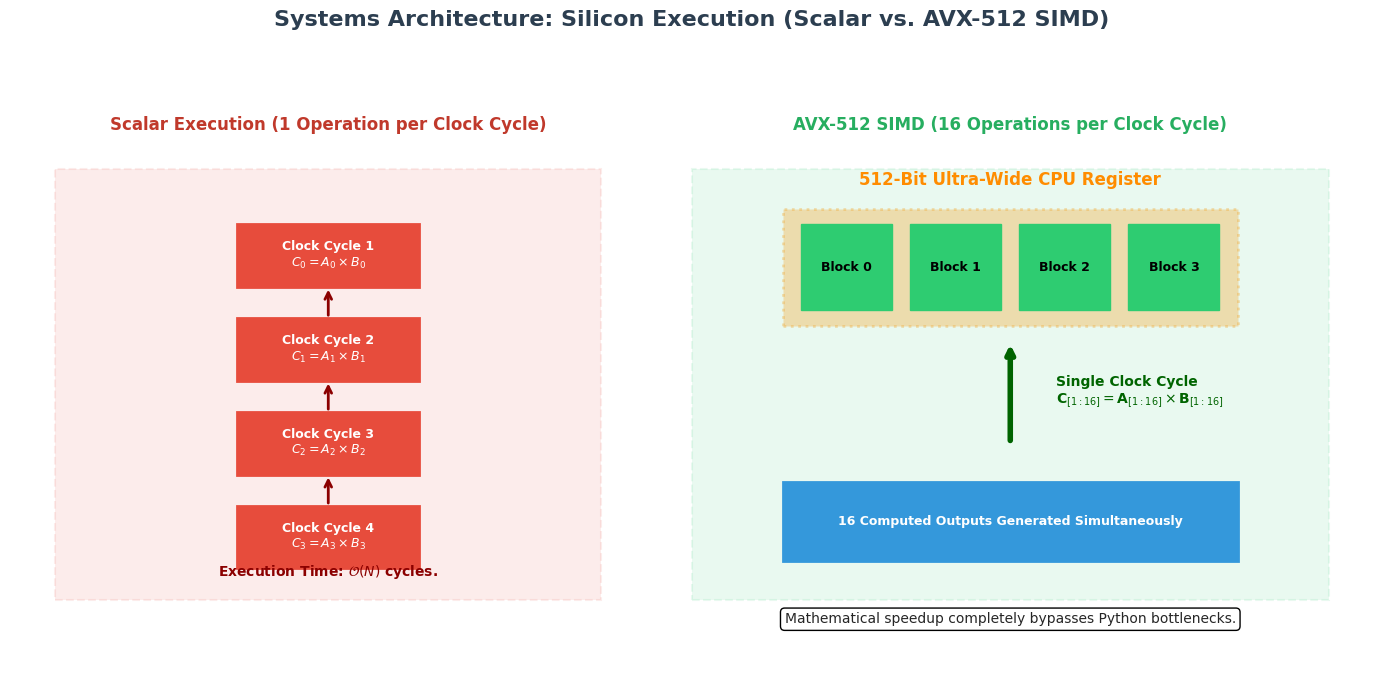

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Systems Architecture: Silicon Execution (Scalar vs. AVX-512 SIMD)", fontsize=16, fontweight='bold', color='#2c3e50')
ax.axis('off')

# -------------------------------------------------------------------
# LEFT: SCALAR EXECUTION (Legacy Python/Unoptimized)
# -------------------------------------------------------------------
ax.text(3.5, 6.5, "Scalar Execution (1 Operation per Clock Cycle)", ha='center', fontweight='bold', fontsize=12, color='#c0392b')
ax.add_patch(patches.Rectangle((0.5, 0.5), 6, 5.5, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', lw=1.5, ls='--'))

# Sequential Data Blocks (Representing the bottleneck)
for i in range(4):
    y_pos = 4.5 - (i * 1.2)
    # CPU Core Processing 1 Block
    ax.add_patch(patches.Rectangle((2.5, y_pos), 2, 0.8, fill=True, color='#e74c3c', edgecolor='black', lw=2))
    ax.text(3.5, y_pos + 0.4, f"Clock Cycle {i+1}\n$C_{i} = A_{i} \\times B_{i}$", ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    if i < 3:
        ax.annotate("", xy=(3.5, y_pos), xytext=(3.5, y_pos - 0.4), arrowprops=dict(arrowstyle="->", lw=2, color="darkred"))

ax.text(3.5, 0.8, "Execution Time: $\\mathcal{O}(N)$ cycles.", ha='center', fontsize=10, fontweight='bold', color='darkred')

# -------------------------------------------------------------------
# RIGHT: SIMD VECTORIZATION (OpenVINO / AVX-512)
# -------------------------------------------------------------------
ax.text(11, 6.5, "AVX-512 SIMD (16 Operations per Clock Cycle)", ha='center', fontweight='bold', fontsize=12, color='#27ae60')
ax.add_patch(patches.Rectangle((7.5, 0.5), 7, 5.5, fill=True, color='#2ecc71', alpha=0.1, edgecolor='black', lw=1.5, ls='--'))

# The Wide 512-bit Register
ax.add_patch(patches.Rectangle((8.5, 4.0), 5, 1.5, fill=True, color='#f39c12', alpha=0.3, edgecolor='darkorange', lw=2, ls='dotted'))
ax.text(11, 5.8, "512-Bit Ultra-Wide CPU Register", ha='center', fontweight='bold', color='darkorange')

# Packed Vector Operations
for i in range(4):
    x_pos = 8.7 + (i * 1.2)
    ax.add_patch(patches.Rectangle((x_pos, 4.2), 1.0, 1.1, fill=True, color='#2ecc71', edgecolor='black', lw=1))
    ax.text(x_pos + 0.5, 4.75, f"Block {i}", ha='center', va='center', color='black', fontsize=9, fontweight='bold')

# The Single Clock Cycle Execution
ax.annotate("", xy=(11, 3.8), xytext=(11, 2.5), arrowprops=dict(arrowstyle="->", lw=4, color="darkgreen"))
ax.text(11.5, 3.15, "Single Clock Cycle\n$\\mathbf{C}_{[1:16]} = \\mathbf{A}_{[1:16]} \\times \\mathbf{B}_{[1:16]}$", ha='left', va='center', fontsize=10, fontweight='bold', color='darkgreen')

# The Finished Wide Vector
ax.add_patch(patches.Rectangle((8.5, 1.0), 5, 1.0, fill=True, color='#3498db', edgecolor='black', lw=2))
ax.text(11, 1.5, "16 Computed Outputs Generated Simultaneously", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

ax.text(11, 0.2, "Mathematical speedup completely bypasses Python bottlenecks.", ha='center', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

plt.xlim(0, 15)
plt.ylim(-0.5, 7.5)
plt.tight_layout()
plt.show()

*(Insight: OpenVINO does not change the math of the neural network; it changes the geometry of how the math enters the physical silicon. By aligning the tensor memory layouts to fit perfectly into the 512-bit registers (the orange box on the right), the CPU performs 16 to 64 calculations in the exact same fraction of a microsecond it normally takes PyTorch to perform just 1 calculation.)*

## Real-World Use Case or Analogy

Think of standard PyTorch vs. OpenVINO like **A Single Bricklayer vs. A Specialized Masonry Crane**:

* **PyTorch/Scalar Execution (The Bricklayer):** You hire a highly skilled bricklayer to build a wall. They pick up one brick (Value A), put mortar on it (Value B), and place it on the wall (Value C). They do this perfectly, over and over. If the wall requires 10,000 bricks, it takes them 10,000 movements. It is incredibly slow, even though the math is correct.
* **OpenVINO (The Factory Architect):** Instead of hiring more bricklayers, you bring in an architect who surveys the exact blueprints of the wall (The Computation Graph).
* **AVX-512 SIMD (The Masonry Crane):** The architect designs a specialized mechanical crane that is exactly 16 bricks wide (**The 512-bit CPU Register**). The crane picks up 16 bricks simultaneously, applies mortar to all 16 simultaneously, and drops them onto the wall perfectly locked into place in one single fluid motion (**One Clock Cycle**).

By compiling models down to OpenVINO IR, MLOps engineers leverage the absolute limit of modern CPU physics, achieving GPU-like latency metrics on global fleets of cheap, ubiquitous CPU servers.